# 0005 --- Field-controlled inference pipeline

End-to-end **field-controlled generation + physical evaluation** for 3D latent diffusion of
porous media, on a single toy **512$^3$ Bentheimer** volume. This notebook joins the two
production scripts into one readable walkthrough:

- `scripts/0004c-porosity-field-generator.py` --- conditions the latent diffusion model on a
  spatially-varying porosity field (Matérn GP), samples a latent, and **chunk-decodes** it to a
  full-resolution binary volume.
- `scripts/0005b-porosity-field-new-metrics-evaluator.py` --- extracts a pore network (SNOW2) and
  computes porosity, absolute permeability, and two-phase flow curves (Pc--Sw, $k_r$) via OpenPNM.

**Pipeline.**

```text
gpdata3c Matérn params  ->  porosity field (latent 64^3)
                            |
bentheimer_pcond.ckpt  ->  flow model  ->  latent (4 x 64^3)
                            |                    |
                            +--------------------+--> chunk_decode_3d --> 512^3 binary volume
                                                                              |
                                                          SNOW2 + OpenPNM  ->  porosity, K_abs, Pc-Sw, kr
```

**Scope / status.** This is a *toy* single-sample run meant to exercise the whole path
(generation **with chunk decoding** + full physical evaluation). The path constants in section 0
still point at `notebooks/exploratory/dfn/...` and `repos/PoreGen/...`, mirroring the current
scripts. They are gathered in one config cell so they can be relocated when those assets move.
Training is out of scope here and will be wired in later.

## 0. Setup & configuration

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import time

import numpy as np
import scipy.special
import torch
import matplotlib.pyplot as plt

# The two production scripts add this aux dir to import `model_loaders`; we do the same so the
# notebook stays faithful to the scripts (same model config, same checkpoint key-remapping).
REPO_ROOT = "/home/ubuntu/repos/DiffSci2"
AUX_DIR = os.path.join(REPO_ROOT, "notebooks", "exploratory", "dfn", "aux")
if AUX_DIR not in sys.path:
    sys.path.insert(0, AUX_DIR)

import diffsci2.models
import diffsci2.nets
from model_loaders import load_flow_model, load_autoencoder
from diffsci2.extra import chunk_decode_2
from diffsci2.extra.matern_gaussian_process import MaternFieldSampler

from poregen.features.snow2 import snow2
from diffsci2.extra.pore.permeability_from_pnm import PoreNetworkPermeability

In [3]:
# --- Configuration --------------------------------------------------------------------------
# NOTE: these paths still live under notebooks/exploratory/ and repos/PoreGen/, mirroring the
# current scripts. Gathered here so they are trivial to relocate later.

STONE = "Bentheimer"
DEVICE = "cuda:6"           # pick a free GPU; do NOT use cuda:7 unless explicitly told to.

# Field-conditional checkpoint (the "_pcond" production model, conditioned on a porosity field).
CHECKPOINT = os.path.join(REPO_ROOT, "savedmodels", "pore", "production", "bentheimer_pcond.ckpt")

# Matérn-GP porosity statistics fitted in latent space (gpdata3c), used to sample the field.
GPDATA_PATH = os.path.join(
    REPO_ROOT, "notebooks", "exploratory", "dfn", "data",
    "gpdata3c", "bentheimer", "bentheimer_porosity_analysis.npz",
)

# Reference micro-CT volume for side-by-side metric comparison (optional; skipped if missing).
REFERENCE_RAW = "/home/ubuntu/repos/PoreGen/saveddata/raw/imperial_college/Bentheimer_1000c_3p0035um.raw"
REFERENCE_SHAPE = (1000, 1000, 1000)

# --- Generation knobs (match 0004c defaults) ------------------------------------------------
PIXEL_SIZE = 512                                  # toy volume edge (multiple of 128)
LATENT_TO_PIXEL_FACTOR = 8                        # VAE downsampling factor F
LATENT_SIZE = PIXEL_SIZE // LATENT_TO_PIXEL_FACTOR  # -> 64
NSTEPS = 21                                       # diffusion sampling steps
GUIDANCE = 1.0                                    # 1.0 = no classifier-free guidance
COARSE_N = 32                                     # coarse grid for the GP field sampler
CHUNK_SIZE = [40, 40, 40]                         # latent-space tile for chunk decoding

# --- Evaluation knobs (match 0005b defaults) ------------------------------------------------
VOXEL_LENGTH = 3.0035e-6     # Bentheimer voxel size [m]
BORDER_CROP = 128            # crop voxels per side before metrics (512 -> 256); 0 disables
CONTACT_ANGLE = 140.0        # drainage [degrees]
SURFACE_TENSION = 0.48       # drainage [N/m]

assert PIXEL_SIZE % (LATENT_TO_PIXEL_FACTOR * 16) == 0, "PIXEL_SIZE must be a multiple of 128"
print(f"Stone={STONE}  device={DEVICE}")
print(f"Generating {PIXEL_SIZE}^3 (latent {LATENT_SIZE}^3), chunk decode = {PIXEL_SIZE > 256}")
torch.manual_seed(0)
np.random.seed(0)

Stone=Bentheimer  device=cuda:6
Generating 512^3 (latent 64^3), chunk decode = True


## 1. Load models

We load exactly what `0004c` loads for the field-conditional case: the `_pcond` flow model
(a `PUNetG` with a `ScalarEmbedder` on the `porosity` key) wrapped in an `SIModule` together with
the production VAE. The same conditioning channel that takes a scalar porosity at training time
accepts a **per-voxel porosity field** at inference --- that is what makes this run *field-controlled*.

In [4]:
t0 = time.time()
flowmodel = load_flow_model(CHECKPOINT, custom_checkpoint_path=True)
vaemodule = load_autoencoder()

flowmoduleconfig = diffsci2.models.SIModuleConfig.from_edm_sigma_space(
    sigma_min=0.002, sigma_max=80.0, sigma_data=0.5,
    initial_norm=20.0, loss_formulation="denoiser",
)
flowmodule = diffsci2.models.SIModule(
    config=flowmoduleconfig, model=flowmodel, autoencoder=vaemodule,
)
flowmodule.to(DEVICE)
print(f"Models loaded in {time.time() - t0:.1f}s")

/home/ubuntu/repos/DiffSci2/notebooks/exploratory/dfn/aux/model_loaders.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(checkpoint)['state_dict']


Loading teacher VAENet model...


Models loaded in 1.6s


## 2. Sample a porosity field (Matérn-GP conditioning)

The conditioning field is a Gaussian process in **logit-porosity** space with a Matérn covariance
whose parameters ($\mu$, $\sigma^2$, $\nu$, $\ell$) were fitted directly in latent space (gpdata3c).
We sample on a coarse grid, interpolate to the latent resolution ($64^3$), then map back to
porosity with a sigmoid. This is the `sample_porosity_field` routine from `0004c`, inlined.

In [5]:
gpdata = np.load(GPDATA_PATH)
print("Matérn params:",
      f"mean_logit={float(gpdata['mean_logit']):.4f}",
      f"sigma^2={float(gpdata['matern_sigma_sq']):.4f}",
      f"nu={float(gpdata['matern_nu']):.4f}",
      f"length_scale={float(gpdata['matern_length_scale']):.4f}")

sampler = MaternFieldSampler(
    mean_val=float(gpdata["mean_logit"]),
    sigma_sq=float(gpdata["matern_sigma_sq"]),
    nu=float(gpdata["matern_nu"]),
    length_scale=float(gpdata["matern_length_scale"]),
)


def sample_porosity_field(sampler, latent_size, coarse_n):
    """Inlined from 0004c.sample_porosity_field (DILATION_FACTOR = 1, latent space)."""
    L = latent_size
    coarse = np.linspace(0.5, L - 0.5, coarse_n)
    sampler.initialize_field_from_grid(coarse, coarse, coarse)
    fine = np.linspace(0.5, L - 0.5, L)
    logit_field = sampler.sample_grid_interpolated(1, fine, fine, fine)[0]
    return scipy.special.expit(logit_field).astype(np.float32)


porosity_field = sample_porosity_field(sampler, LATENT_SIZE, COARSE_N)
print(f"porosity field shape={porosity_field.shape}, "
      f"range=[{porosity_field.min():.4f}, {porosity_field.max():.4f}], "
      f"mean={porosity_field.mean():.4f}")

Matérn params: mean_logit=-1.3000 sigma^2=0.0138 nu=1.5000 length_scale=11.2992


porosity field shape=(64, 64, 64), range=[0.1402, 0.2807], mean=0.2136


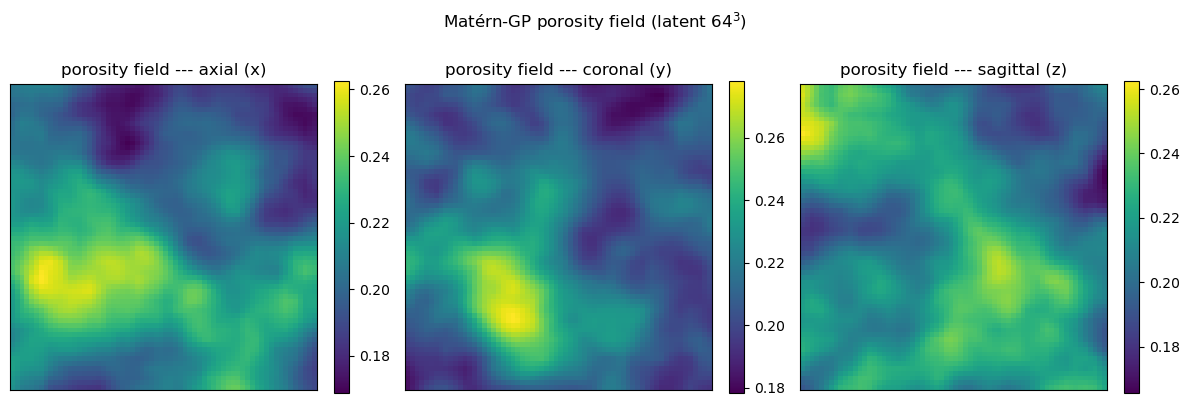

In [6]:
# Visualize three orthogonal mid-slices of the conditioning field.
mid = LATENT_SIZE // 2
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (sl, name) in zip(
    axes,
    [(porosity_field[mid], "axial (x)"),
     (porosity_field[:, mid], "coronal (y)"),
     (porosity_field[:, :, mid], "sagittal (z)")],
):
    im = ax.imshow(sl, cmap="viridis")
    ax.set_title(f"porosity field --- {name}")
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Matérn-GP porosity field (latent 64$^3$)", y=1.02)
fig.tight_layout(); plt.show()

## 3. Generate a 512$^3$ volume with chunk decoding

Two stages, exactly as in `0004c.generate_volume_from_conditioning` for `pixel_size > 256`:

1. **Latent sampling.** Run the diffusion sampler in latent space to get a $4\times 64^3$ latent,
   conditioned on the porosity field. `return_latents=True` stops before decoding.
2. **Chunk decode.** Tile the latent and decode tile-by-tile with cached normalization statistics,
   so peak GPU memory is independent of the output size (see tutorial 0002).

Finally we binarize with the per-volume mean threshold (`x > x.mean()`), matching the generator's
default. Convention: **solid = True/1, pore = False/0**.

In [7]:
y = {"porosity": torch.tensor(porosity_field, dtype=torch.float32)}

t0 = time.time()
# Stage 1: sample the latent (no decode yet).
x_latent = flowmodule.sample(
    1, shape=[4, LATENT_SIZE, LATENT_SIZE, LATENT_SIZE],
    y=y, nsteps=NSTEPS, is_latent_shape=True, return_latents=True, guidance=GUIDANCE,
)
print(f"latent sampled: shape={tuple(x_latent.shape)} in {time.time() - t0:.1f}s")

# Stage 2: chunk decode to full resolution.
t0 = time.time()
chunk_decode_2.prepare_decoder_for_cached_decode(vaemodule.decoder)
vaemodule.decoder.to(DEVICE)
x = chunk_decode_2.chunk_decode_3d(
    vaemodule.decoder, x_latent, CHUNK_SIZE,
    device=DEVICE, periodicity=[False, False, False], use_cached_norms=True,
)
x = x[0][0].cpu().numpy()
torch.cuda.empty_cache()
print(f"decoded volume: shape={x.shape} in {time.time() - t0:.1f}s")

# Binarize (solid = True where x > mean).
volume = (x > x.mean())
print(f"binary volume: porosity (pore fraction) = {1 - volume.mean():.4f}")

/opt/persistence/repos/DiffSci2/diffsci2/models/karras/flowfield.py:897: UserWarning: Moving y to device: cuda:6
  warnings.warn("Moving y to device: {}".format(self.device))


latent sampled: shape=(1, 4, 64, 64, 64) in 4.8s


decoded volume: shape=(512, 512, 512) in 162.9s


binary volume: porosity (pore fraction) = 0.2162


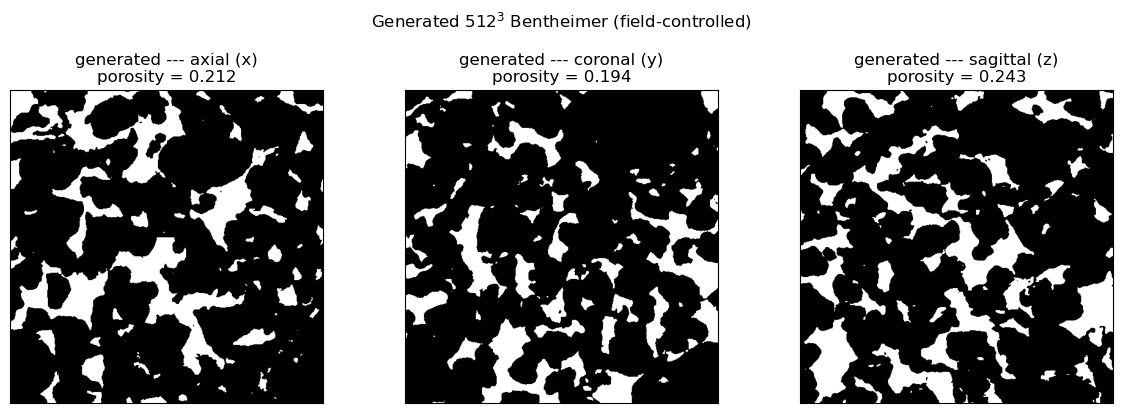

In [8]:
# Visualize three orthogonal mid-slices of the generated binary volume (solid = black).
mid = PIXEL_SIZE // 2
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (sl, name) in zip(
    axes,
    [(volume[mid], "axial (x)"),
     (volume[:, mid], "coronal (y)"),
     (volume[:, :, mid], "sagittal (z)")],
):
    ax.imshow(sl, cmap="gray_r")
    ax.set_title(f"generated --- {name}\nporosity = {1 - sl.mean():.3f}")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Generated {PIXEL_SIZE}$^3$ {STONE} (field-controlled)", y=1.02)
fig.tight_layout(); plt.show()

## 4. Evaluate physical metrics (SNOW2 + pore-network two-phase flow)

This is `0005b` on the single generated volume. We first crop the borders (boundary artifacts),
extract a pore network with **SNOW2** (which expects pore = 1, so we invert), then build a
`PoreNetworkPermeability` and compute:

- **porosity** = pore fraction,
- **absolute permeability** $K_{abs}$ along x/y/z,
- a **drainage** simulation (contact angle, surface tension) and the resulting
  **capillary-pressure** ($P_c$--$S_w$) and **relative-permeability** ($k_r$) curves.

In [9]:
def center_crop(vol, border):
    if border <= 0:
        return vol
    return vol[border:-border, border:-border, border:-border]


eval_volume = center_crop(volume, BORDER_CROP)
print(f"eval volume shape={eval_volume.shape}  (border_crop={BORDER_CROP})")

# SNOW2 expects pore space = 1; our convention is pore = 0 -> invert.
t0 = time.time()
partitioning = snow2(1 - eval_volume.astype(np.uint8), voxel_size=1.0)
network = partitioning.network
print(f"SNOW2 network extracted in {time.time() - t0:.1f}s  "
      f"(n_pores={network['pore.coords'].shape[0]})")

eval volume shape=(256, 256, 256)  (border_crop=128)


SNOW2 network extracted in 19.5s  (n_pores=1229)


In [10]:
t0 = time.time()
pnp = PoreNetworkPermeability.from_porespy_network(
    network, volume_length=eval_volume.shape[0], voxel_size=VOXEL_LENGTH,
)

abs_perm = pnp.calculate_absolute_permeability()
_ = pnp.run_drainage_simulation(contact_angle=CONTACT_ANGLE, surface_tension=SURFACE_TENSION)
rel_perm = pnp.calculate_relative_permeability_curves()

porosity = float(1 - eval_volume.mean())
print(f"two-phase analysis in {time.time() - t0:.1f}s")
print(f"  porosity         = {porosity:.4f}")
print(f"  K_abs (x,y,z) mD = ({abs_perm.K_x_physical * 1e15:.2f}, "
      f"{abs_perm.K_y_physical * 1e15:.2f}, {abs_perm.K_z_physical * 1e15:.2f})")
print(f"  K_abs mean    mD = {abs_perm.K_mean_physical * 1e15:.2f}")

Performing drainage simulation:   0%|          | 0/25 [00:00<?, ?it/s]

two-phase analysis in 0.9s
  porosity         = 0.2372
  K_abs (x,y,z) mD = (882.46, 3739.51, 2877.40)
  K_abs mean    mD = 2499.79


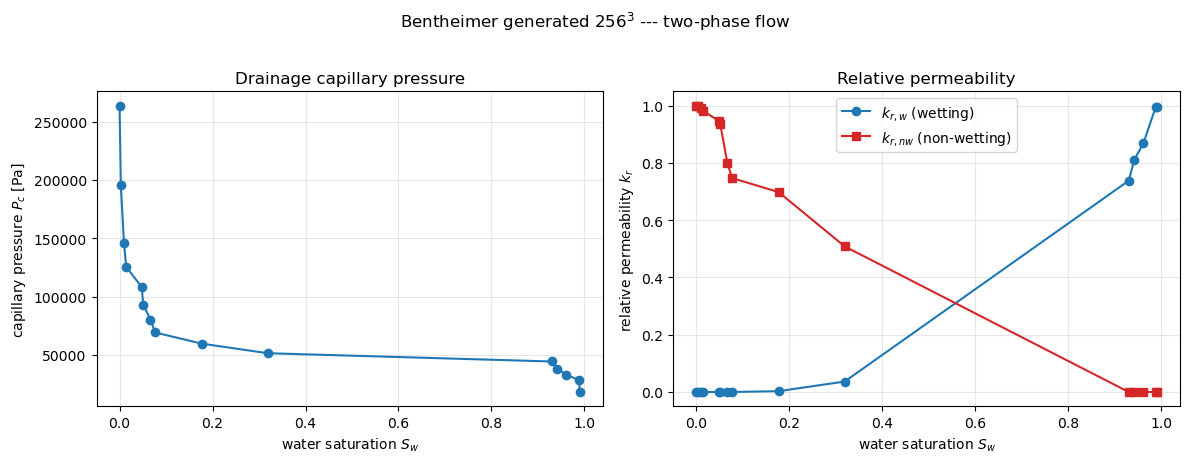

In [11]:
# Capillary pressure and relative permeability curves.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(rel_perm.Sw, rel_perm.Pc, "o-", color="C0")
axes[0].set_xlabel("water saturation $S_w$")
axes[0].set_ylabel("capillary pressure $P_c$ [Pa]")
axes[0].set_title("Drainage capillary pressure")
axes[0].grid(alpha=0.3)

axes[1].plot(rel_perm.Sw, rel_perm.kr_wetting_mean, "o-", color="C0", label="$k_{r,w}$ (wetting)")
axes[1].plot(rel_perm.Sw, rel_perm.kr_nonwetting_mean, "s-", color="C3", label="$k_{r,nw}$ (non-wetting)")
axes[1].set_xlabel("water saturation $S_w$")
axes[1].set_ylabel("relative permeability $k_r$")
axes[1].set_title("Relative permeability")
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle(f"{STONE} generated {eval_volume.shape[0]}$^3$ --- two-phase flow", y=1.02)
fig.tight_layout(); plt.show()

## 5. (Optional) Reference micro-CT comparison

For a quick sanity check, compute the same scalar metrics on the real Bentheimer micro-CT volume.
This is the heaviest cell (full 1000$^3$ SNOW2) --- skip it on a quick pass. It is the
`reference` branch of `0005b`.

In [12]:
RUN_REFERENCE = False  # set True to run the full reference comparison (slow: 1000^3 SNOW2)

if RUN_REFERENCE and os.path.exists(REFERENCE_RAW):
    ref = np.fromfile(REFERENCE_RAW, dtype=np.uint8).reshape(REFERENCE_SHAPE)
    print(f"reference shape={ref.shape}, porosity={1 - ref.mean():.4f}")
    ref_net = snow2(1 - ref, voxel_size=1.0).network
    ref_pnp = PoreNetworkPermeability.from_porespy_network(
        ref_net, volume_length=ref.shape[0], voxel_size=VOXEL_LENGTH,
    )
    ref_K = ref_pnp.calculate_absolute_permeability()
    print(f"reference porosity = {1 - ref.mean():.4f}")
    print(f"reference K_abs mean = {ref_K.K_mean_physical * 1e15:.2f} mD")
    print(f"generated K_abs mean = {abs_perm.K_mean_physical * 1e15:.2f} mD")
else:
    print("Reference comparison skipped (set RUN_REFERENCE=True to enable).")

Reference comparison skipped (set RUN_REFERENCE=True to enable).


## Summary

This notebook ran the full field-controlled inference path on one toy 512$^3$ Bentheimer volume:
Matérn-GP porosity field $\rightarrow$ latent diffusion $\rightarrow$ chunk decode $\rightarrow$
SNOW2 $\rightarrow$ porosity / $K_{abs}$ / $P_c$--$S_w$ / $k_r$.

**Next steps (later work):**
- relocate the `notebooks/exploratory/...` and `repos/PoreGen/...` asset paths into a stable
  config once those assets move;
- loop over multiple fields / samples for distributional comparison against the reference;
- wire in the unconditional / 129 / 257 training-resolution cases from `0004c`;
- prepend a training section once it is ready.